In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from src.config import PROCESSED_DATA_PATH

In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH)

In [4]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,3600.0,36 months,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,...,0.0,2765.0,29.7,13.0,Individual,677.0,0.065455,0.002237,12.334018,0
1,24700.0,36 months,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,...,0.0,21470.0,19.2,38.0,Individual,717.0,0.380000,0.012620,16.000000,0
2,20000.0,60 months,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,...,0.0,7869.0,56.2,18.0,Joint App,697.0,0.317460,0.006868,15.331964,0
3,10400.0,60 months,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,0.0,21929.0,64.5,35.0,Individual,697.0,0.099585,0.002776,17.500342,0
4,11950.0,36 months,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,0.0,8822.0,68.4,6.0,Individual,692.0,0.351471,0.011917,28.167009,0


In [5]:
df.shape

(1345310, 24)

In [6]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [7]:
df['term'] = df['term'].str.replace(' months', '').astype(int)

In [8]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,application_type,fico_score,loan_to_income,installment_to_income,credit_history_years,loan_default
0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,55000.0,Not Verified,...,0.0,2765.0,29.7,13.0,Individual,677.0,0.065455,0.002237,12.334018,0
1,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,65000.0,Not Verified,...,0.0,21470.0,19.2,38.0,Individual,717.0,0.380000,0.012620,16.000000,0
2,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,63000.0,Not Verified,...,0.0,7869.0,56.2,18.0,Joint App,697.0,0.317460,0.006868,15.331964,0
3,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,0.0,21929.0,64.5,35.0,Individual,697.0,0.099585,0.002776,17.500342,0
4,11950.0,36,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,0.0,8822.0,68.4,6.0,Individual,692.0,0.351471,0.011917,28.167009,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   loan_amnt              1345310 non-null  float64
 1   term                   1345310 non-null  int64  
 2   int_rate               1345310 non-null  float64
 3   installment            1345310 non-null  float64
 4   grade                  1345310 non-null  object 
 5   sub_grade              1345310 non-null  object 
 6   emp_length             1266799 non-null  float64
 7   home_ownership         1345310 non-null  object 
 8   annual_inc             1345310 non-null  float64
 9   verification_status    1345310 non-null  object 
 10  purpose                1345310 non-null  object 
 11  dti                    1344936 non-null  float64
 12  delinq_2yrs            1345310 non-null  float64
 13  open_acc               1345310 non-null  float64
 14  pub_rec           

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1345310.0,14419.972014,8717.050787,500.000000,8000.000000,12000.000000,20000.000000,4.000000e+04
term,1345310.0,41.790196,10.268321,36.000000,36.000000,36.000000,36.000000,6.000000e+01
int_rate,1345310.0,13.239619,4.768716,5.310000,9.750000,12.740000,15.990000,3.099000e+01
installment,1345310.0,438.075533,261.512604,4.930000,248.480000,375.430000,580.730000,1.719830e+03
emp_length,1266799.0,5.965873,3.691166,0.000000,2.000000,6.000000,10.000000,1.000000e+01
annual_inc,1345310.0,76247.636414,69925.098427,0.000000,45780.000000,65000.000000,90000.000000,1.099920e+07
dti,1344936.0,18.282667,11.160446,-1.000000,11.790000,17.610000,24.060000,9.990000e+02
delinq_2yrs,1345310.0,0.317794,0.877992,0.000000,0.000000,0.000000,0.000000,3.900000e+01
open_acc,1345310.0,11.593520,5.473789,0.000000,8.000000,11.000000,14.000000,9.000000e+01
pub_rec,1345310.0,0.215276,0.601865,0.000000,0.000000,0.000000,0.000000,8.600000e+01


In [11]:
df['loan_default'].value_counts()

loan_default
0    1076751
1     268559
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

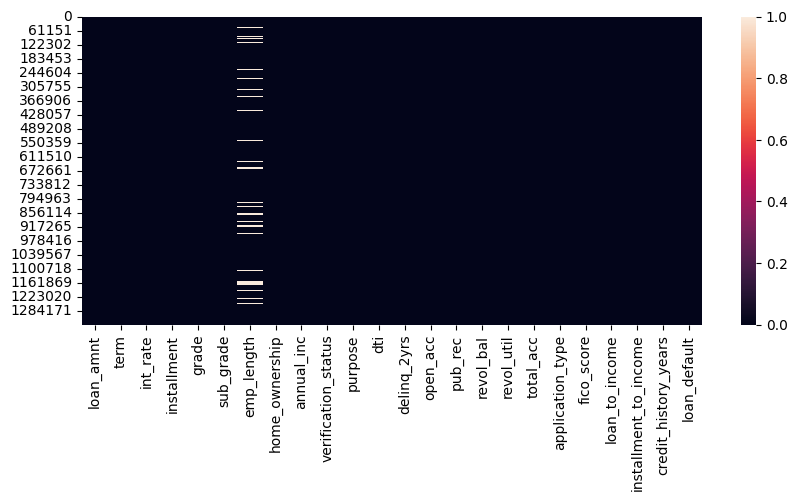

In [15]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull())
plt.show()

In [16]:
df.isnull().sum()

loan_amnt                    0
term                         0
int_rate                     0
installment                  0
grade                        0
sub_grade                    0
emp_length               78511
home_ownership               0
annual_inc                   0
verification_status          0
purpose                      0
dti                        374
delinq_2yrs                  0
open_acc                     0
pub_rec                      0
revol_bal                    0
revol_util                 857
total_acc                    0
application_type             0
fico_score                   0
loan_to_income             361
installment_to_income      361
credit_history_years         0
loan_default                 0
dtype: int64

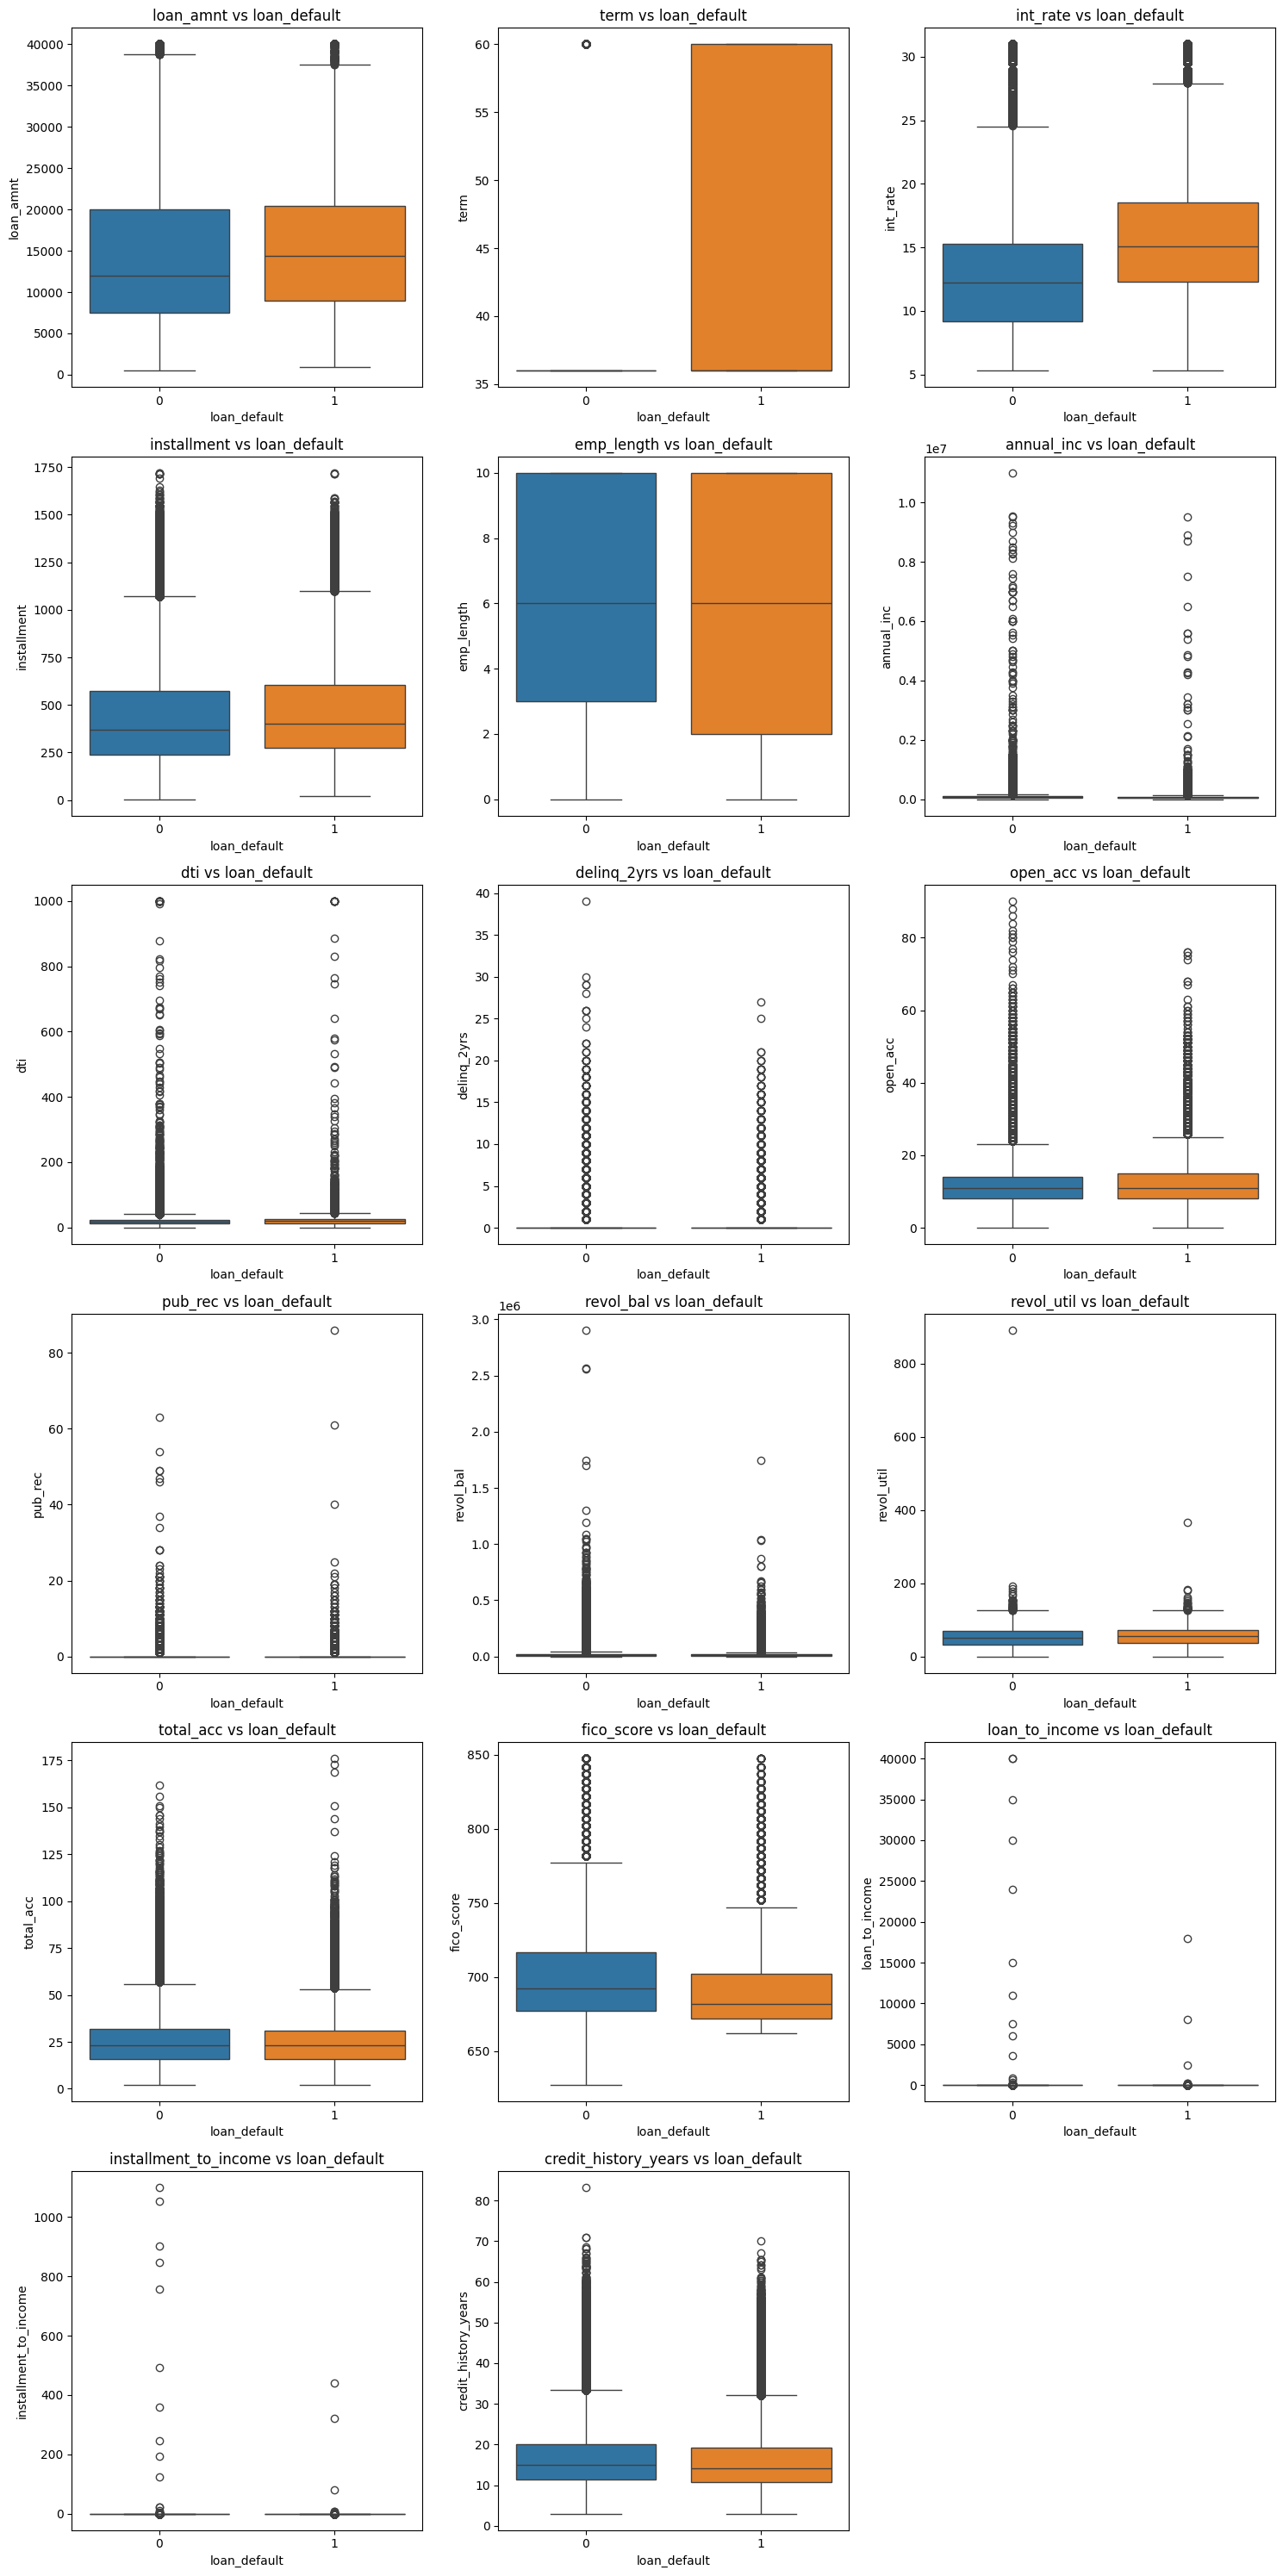

In [17]:
def show_outliers(a, target='loan_default'):

    numerical_cols = a.select_dtypes(include='number').columns
    numerical_cols = numerical_cols.drop(target, errors='ignore')

    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 5 * n_rows)
    )

    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):

        sns.boxplot(
            data=a,
            x=target,
            y=col,
            hue=target,
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel(col)

    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


show_outliers(df)

In [18]:
def count_outliers_by_class(df, target, num_col):

    result = []

    # Total observations
    total_rows = len(df)

    # Total observations in each class
    class_counts = df[target].value_counts()

    for cls in df[target].dropna().unique():

        data = df.loc[df[target] == cls, num_col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Identify outliers
        outlier_mask = (data < lower) | (data > upper)

        outliers = outlier_mask.sum()

        # Total outliers across ALL classes will be calculated later
        result.append({
            'Class': cls,
            'Total': len(data),
            'Class_%_Of_Total': round(
                class_counts[cls] / total_rows * 100, 2
            ),
            'Q1': Q1,
            'Q3': Q3,
            'Lower_Bound': lower,
            'Upper_Bound': upper,
            'Outlier_Range': f'< {lower:.2f} OR > {upper:.2f}',
            'Outliers': outliers,
            'Outlier_%_Within_Class': round(
                outliers / len(data) * 100, 2
            )
        })

    result = pd.DataFrame(result)

    # Total number of outliers across all classes
    total_outliers = result['Outliers'].sum()

    # Percentage of all outliers belonging to each class
    result['Outlier_%_Of_All_Outliers'] = round(
        result['Outliers'] / total_outliers * 100, 2
    )

    return result

In [19]:
numerical_cols = df.select_dtypes(["int64", "float64","int32"])

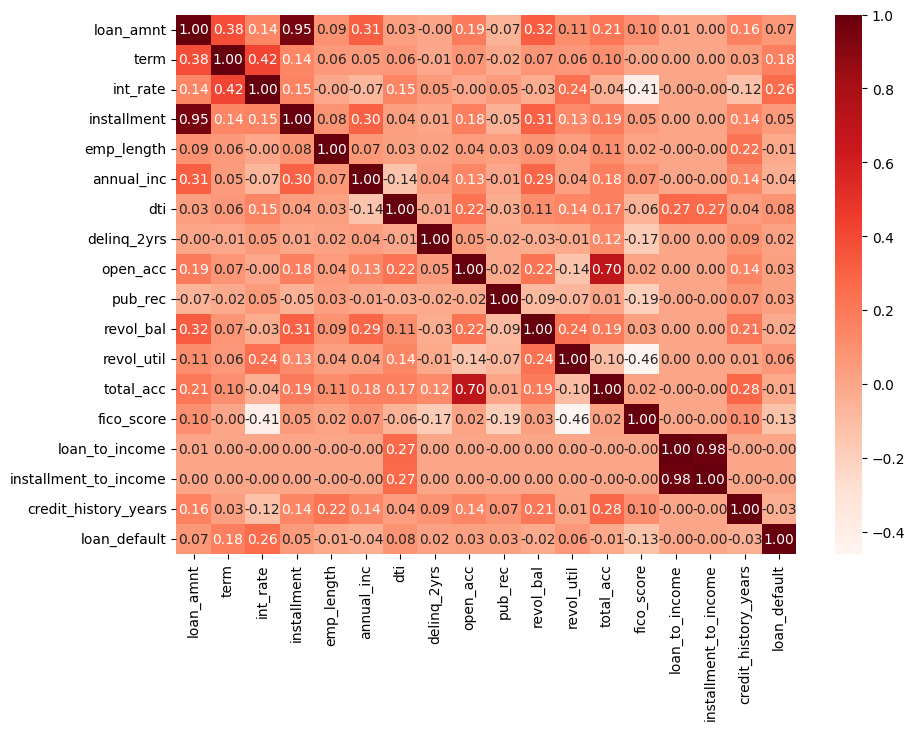

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f'
)
plt.show()

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [22]:
from src.config import (
    PROCESSED_DATA_PATH,
    TARGET,
    TEST_SIZE,
    RANDOM_STATE,
)
from src.preprocessing import OutlierCapper

In [23]:
from sklearn.model_selection import train_test_split

# 1. Split FIRST on the full natural-distribution data
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Before undersampling")
print("Train:", y_train.value_counts().to_dict())
print("Test :", y_test.value_counts().to_dict())   # stays ~80/20

# 2. Undersample ONLY the training set (right here, once)
train_df = X_train.copy()
train_df[TARGET] = y_train

majority = train_df[train_df[TARGET] == 0]
minority = train_df[train_df[TARGET] == 1]

majority_down = majority.sample(n=len(minority), random_state=RANDOM_STATE)

train_balanced = (
    pd.concat([majority_down, minority])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_train = train_balanced.drop(columns=[TARGET])
y_train = train_balanced[TARGET].astype(int)

print("\nAfter undersampling")
print("Train:", y_train.value_counts().to_dict())   # 50/50
print("Test :", y_test.value_counts().to_dict())    # untouched ~80/20



# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# Preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="passthrough"
)


# Models
models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "random_forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "xgboost": XGBClassifier(
        random_state=RANDOM_STATE
        
    )
}


# Train each model
trained_models = {}

Before undersampling
Train: {0: 861401, 1: 214847}
Test : {0: 215350, 1: 53712}

After undersampling
Train: {1: 214847, 0: 214847}
Test : {0: 215350, 1: 53712}


In [24]:
from sklearn.metrics import average_precision_score,roc_auc_score,confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report

In [25]:
for name, model in models.items():

    

    pipeline = Pipeline(
        steps=[
            ("outlier_capper", OutlierCapper()),
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_train_prob = pipeline.predict_proba(X_train)[:, 1]

    # Metrics
    train_accuracy = pipeline.score(X_train, y_train)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_prob)

    # Print results
    print(f"{name}")    
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1       : {train_f1:.4f}")
    print(f"ROC-AUC  : {train_roc_auc:.4f}")
    print("-" * 40)

logistic_regression
Accuracy : 0.6523
Precision: 0.6461
Recall   : 0.6734
F1       : 0.6595
ROC-AUC  : 0.7108
----------------------------------------
random_forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
ROC-AUC  : 1.0000
----------------------------------------
xgboost
Accuracy : 0.6818
Precision: 0.6745
Recall   : 0.7028
F1       : 0.6884
ROC-AUC  : 0.7505
----------------------------------------


In [26]:
results = []

for name, model in trained_models.items():

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6403     0.3134  0.6737 0.4278   0.7106  0.3744
      random_forest    0.6442     0.3139  0.6596 0.4253   0.7063  0.3614
            xgboost    0.6474     0.3202  0.6823 0.4359   0.7205  0.3863


In [27]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt


print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance (untouched):")
print(y_test.value_counts(normalize=True))

# Preprocessing (same as before)
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Stratified CV - preserves class ratio in every fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train class balance:
loan_default
1    0.5
0    0.5
Name: proportion, dtype: float64

Test class balance (untouched):
loan_default
0    0.800373
1    0.199627
Name: proportion, dtype: float64


In [28]:
TEST_SIZE

0.2

In [44]:
print(y_train.shape)
print(y_test.shape)

(429694,)
(269062,)


In [50]:
print(f'train: \n {y_train.value_counts()}')
print(f'test: \n {y_test.value_counts()}')

train: 
 loan_default
1    214847
0    214847
Name: count, dtype: int64
test: 
 loan_default
0    215350
1     53712
Name: count, dtype: int64


In [31]:
# NOTE: step name must exactly match the prefix used in each param grid
# below (LR__, RF__, GBM__, XGB__) - that's what RandomizedSearchCV uses
# to route hyperparameters to the right step.

pipelines = {
    "logistic_regression": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("LR", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000))
    ]),
    "random_forest": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("RF", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    
    
    "xgboost": Pipeline(steps=[
        ("outlier_capper", OutlierCapper()),
        ("preprocessor", preprocessor),
        ("XGB", XGBClassifier(
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

# Your existing param grids (unchanged, prefixes already match step names above)
param_range = [2, 3, 4, 5, 6]
param_range_fl = [0.6, 0.8, 1.0]
n_estimators = [50, 100, 150, 200, 300]
learning_rates = [0.01, 0.03, 0.05, 0.1]

param_grids = {
    
    "logistic_regression": {
        "LR__penalty": ["l1", "l2"],
        "LR__C": [0.01, 0.1, 0.5, 1.0, 10.0],
        "LR__solver": ["liblinear"]
    },
    "random_forest": {
        "RF__min_samples_leaf": [1, 2, 3, 5, 10],
        "RF__max_depth": param_range,
        "RF__min_samples_split": [2, 3, 4, 5, 10, 20],
        "RF__n_estimators": n_estimators,
        "RF__max_features": ["sqrt", "log2"]
    },
 
    
    "xgboost": {
        "XGB__learning_rate": learning_rates,
        "XGB__max_depth": param_range,
        "XGB__min_child_weight": [1, 2, 3, 5],
        "XGB__subsample": param_range_fl,
        "XGB__colsample_bytree": param_range_fl,
        "XGB__n_estimators": n_estimators
    }
}

In [32]:

# Evaluation metric
# F1 balances precision and recall for the positive/default class.
SCORING = "f1"

# Number of randomly sampled parameter combinations
N_ITER = 5


search_results = {}
best_estimators = {}


for name, pipeline in pipelines.items():

    print(f"\n{'=' * 60}")
    print(f"Tuning: {name}")
    print(f"{'=' * 60}")

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    # No GBM-specific sample_weight is needed anymore.
    search.fit(X_train, y_train)

    search_results[name] = search
    best_estimators[name] = search.best_estimator_

    print(f"Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")


Tuning: logistic_regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6595
Best params: {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}

Tuning: random_forest
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6667
Best params: {'RF__n_estimators': 100, 'RF__min_samples_split': 5, 'RF__min_samples_leaf': 3, 'RF__max_features': 'log2', 'RF__max_depth': 5}

Tuning: xgboost
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV f1: 0.6672
Best params: {'XGB__subsample': 0.6, 'XGB__n_estimators': 300, 'XGB__min_child_weight': 2, 'XGB__max_depth': 5, 'XGB__learning_rate': 0.1, 'XGB__colsample_bytree': 1.0}


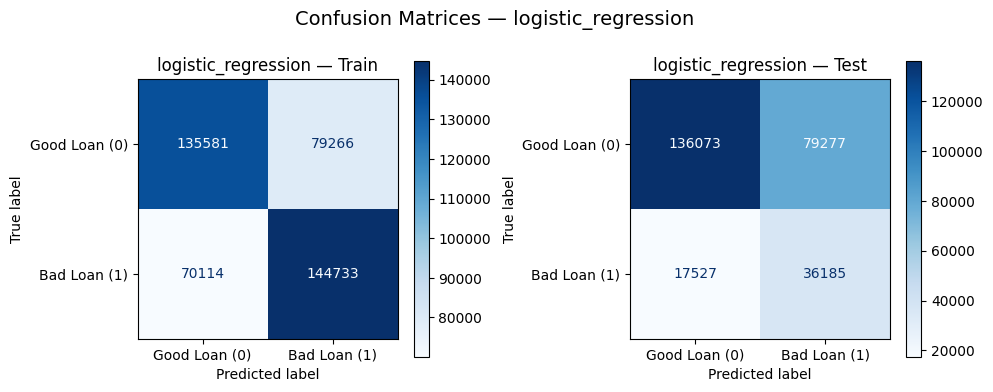

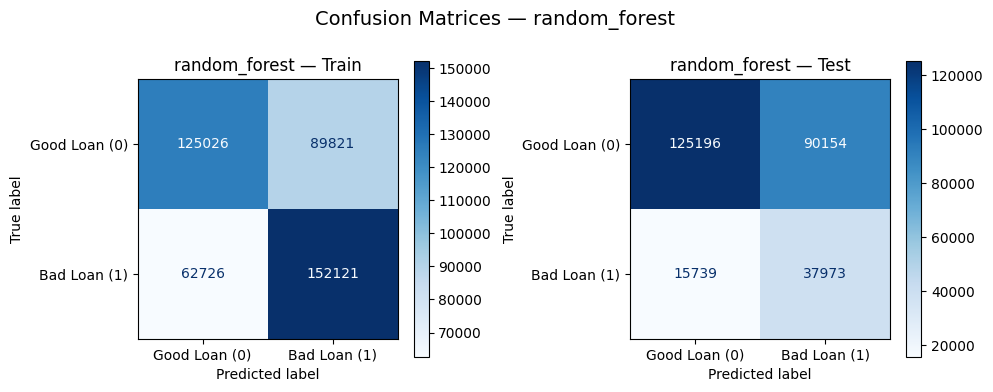

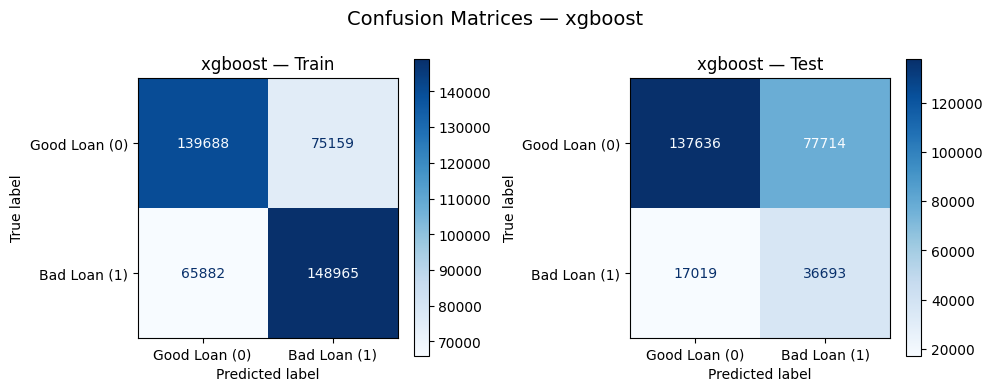


TRAIN SET RESULTS:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6524     0.6461  0.6737 0.6596   0.7108  0.6937
      random_forest    0.6450     0.6287  0.7080 0.6660   0.7028  0.6834
            xgboost    0.6718     0.6647  0.6934 0.6787   0.7374  0.7249

TEST SET RESULTS:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
logistic_regression    0.6402     0.3134  0.6737 0.4278   0.7106  0.3744
      random_forest    0.6064     0.2964  0.7070 0.4177   0.7015  0.3602
            xgboost    0.6479     0.3207  0.6831 0.4365   0.7223  0.3897


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

CLASS_NAMES = ["Good Loan (0)", "Bad Loan (1)"]

train_results = []
test_results = []

for name, model in best_estimators.items():

    # =========================
    # Predictions: TRAIN
    # =========================
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # =========================
    # Predictions: TEST
    # =========================
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # Store TRAIN metrics
    # =========================
    train_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1": f1_score(y_train, y_train_pred),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob),
        "PR-AUC": average_precision_score(y_train, y_train_prob)
    })

    # =========================
    # Store TEST metrics
    # =========================
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob),
        "PR-AUC": average_precision_score(y_test, y_test_prob)
    })

    # =========================
    # Train and Test Confusion
    # Matrices Side by Side
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay(
        confusion_matrix(y_train, y_train_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=axes[0], cmap="Blues", values_format="d")

    axes[0].set_title(f"{name} — Train")

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_test_pred),
        display_labels=CLASS_NAMES
    ).plot(ax=axes[1], cmap="Blues", values_format="d")

    axes[1].set_title(f"{name} — Test")

    fig.suptitle(f"Confusion Matrices — {name}", fontsize=14)
    plt.tight_layout()
    plt.show()


# ==========================================
# Create Train and Test Result DataFrames
# ==========================================

train_results_df = pd.DataFrame(train_results)
test_results_df = pd.DataFrame(test_results)


# ==========================================
# Display Train Results
# ==========================================

print("\nTRAIN SET RESULTS:")
print(train_results_df.round(4).to_string(index=False))


# ==========================================
# Display Test Results
# ==========================================

print("\nTEST SET RESULTS:")
print(test_results_df.round(4).to_string(index=False))

In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Best XGBoost pipeline, already refit on the full balanced train set
best_xgb = best_estimators["xgboost"]

# See exactly which params won
print("Best XGB params:", search_results["xgboost"].best_params_)
print(f"Best CV {SCORING}: {search_results['xgboost'].best_score_:.4f}")

# No .fit() needed here, it's already fitted


# =========================
# TRAIN SET
# =========================
y_train_pred = best_xgb.predict(X_train)
y_train_proba = best_xgb.predict_proba(X_train)[:, 1]

print("=" * 60)
print("XGBOOST - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")


Best XGB params: {'XGB__subsample': 0.6, 'XGB__n_estimators': 300, 'XGB__min_child_weight': 2, 'XGB__max_depth': 5, 'XGB__learning_rate': 0.1, 'XGB__colsample_bytree': 1.0}
Best CV f1: 0.6672
XGBOOST - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.68      0.65      0.66    214847
 Bad Loan (1)       0.66      0.69      0.68    214847

     accuracy                           0.67    429694
    macro avg       0.67      0.67      0.67    429694
 weighted avg       0.67      0.67      0.67    429694

Confusion Matrix:
[[139688  75159]
 [ 65882 148965]]

Metrics:
Accuracy : 0.6718
Precision: 0.6647
Recall   : 0.6934
F1       : 0.6787
ROC-AUC  : 0.7374


In [35]:
# =========================
# TEST SET
# =========================
y_test_pred = best_xgb.predict(X_test)
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("XGBOOST - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")




XGBOOST - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.89      0.64      0.74    215350
 Bad Loan (1)       0.32      0.68      0.44     53712

     accuracy                           0.65    269062
    macro avg       0.61      0.66      0.59    269062
 weighted avg       0.78      0.65      0.68    269062

Confusion Matrix:
[[137636  77714]
 [ 17019  36693]]

Metrics:
Accuracy : 0.6479
Precision: 0.3207
Recall   : 0.6831
F1       : 0.4365
ROC-AUC  : 0.7223


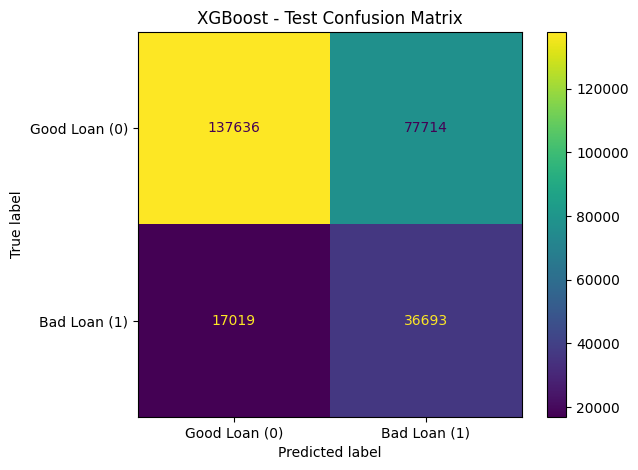

In [36]:
# =========================
# CONFUSION MATRIX PLOT
# =========================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Good Loan (0)", "Bad Loan (1)"],
    values_format="d"
)

plt.title("XGBoost - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [52]:
y_test.value_counts()

loan_default
0    215350
1     53712
Name: count, dtype: int64

In [53]:
36693+17019

53712

In [55]:
(36693/53712)*100

68.31434316353887

In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Best Logistic Regression params from RandomizedSearchCV:
# {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}
best_lr = best_estimators["logistic_regression"]

print("Best LR params:", search_results["logistic_regression"].best_params_)
print(f"Best CV {SCORING}: {search_results['logistic_regression'].best_score_:.4f}")

# =========================
# TRAIN SET
# =========================
y_train_pred = best_lr.predict(X_train)
y_train_proba = best_lr.predict_proba(X_train)[:, 1]

print("=" * 60)
print("LOGISTIC REGRESSION - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")

Best LR params: {'LR__solver': 'liblinear', 'LR__penalty': 'l2', 'LR__C': 0.5}
Best CV f1: 0.6595
LOGISTIC REGRESSION - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.66      0.63      0.64    214847
 Bad Loan (1)       0.65      0.67      0.66    214847

     accuracy                           0.65    429694
    macro avg       0.65      0.65      0.65    429694
 weighted avg       0.65      0.65      0.65    429694

Confusion Matrix:
[[135581  79266]
 [ 70114 144733]]

Metrics:
Accuracy : 0.6524
Precision: 0.6461
Recall   : 0.6737
F1       : 0.6596
ROC-AUC  : 0.7108


In [38]:
# =========================
# TEST SET
# =========================
y_test_pred = best_lr.predict(X_test)
y_test_proba = best_lr.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")



LOGISTIC REGRESSION - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.89      0.63      0.74    215350
 Bad Loan (1)       0.31      0.67      0.43     53712

     accuracy                           0.64    269062
    macro avg       0.60      0.65      0.58    269062
 weighted avg       0.77      0.64      0.68    269062

Confusion Matrix:
[[136073  79277]
 [ 17527  36185]]

Metrics:
Accuracy : 0.6402
Precision: 0.3134
Recall   : 0.6737
F1       : 0.4278
ROC-AUC  : 0.7106


In [39]:
# Best Random Forest params from RandomizedSearchCV:
# {'RF__n_estimators': 300, 'RF__min_samples_split': 5,
#  'RF__min_samples_leaf': 5, 'RF__max_features': 'log2', 'RF__max_depth': 6}
best_rf = best_estimators["random_forest"]

print("Best RF params:", search_results["random_forest"].best_params_)
print(f"Best CV {SCORING}: {search_results['random_forest'].best_score_:.4f}")

# =========================
# TRAIN SET
# =========================
y_train_pred = best_rf.predict(X_train)
y_train_proba = best_rf.predict_proba(X_train)[:, 1]

print("=" * 60)
print("RANDOM FOREST - TRAINING SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_train, y_train_proba):.4f}")

Best RF params: {'RF__n_estimators': 100, 'RF__min_samples_split': 5, 'RF__min_samples_leaf': 3, 'RF__max_features': 'log2', 'RF__max_depth': 5}
Best CV f1: 0.6667
RANDOM FOREST - TRAINING SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.67      0.58      0.62    214847
 Bad Loan (1)       0.63      0.71      0.67    214847

     accuracy                           0.64    429694
    macro avg       0.65      0.64      0.64    429694
 weighted avg       0.65      0.64      0.64    429694

Confusion Matrix:
[[125026  89821]
 [ 62726 152121]]

Metrics:
Accuracy : 0.6450
Precision: 0.6287
Recall   : 0.7080
F1       : 0.6660
ROC-AUC  : 0.7028


In [40]:
# =========================
# TEST SET
# =========================
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("RANDOM FOREST - TEST SET")
print("=" * 60)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Good Loan (0)", "Bad Loan (1)"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nMetrics:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")



RANDOM FOREST - TEST SET

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.89      0.58      0.70    215350
 Bad Loan (1)       0.30      0.71      0.42     53712

     accuracy                           0.61    269062
    macro avg       0.59      0.64      0.56    269062
 weighted avg       0.77      0.61      0.65    269062

Confusion Matrix:
[[125196  90154]
 [ 15739  37973]]

Metrics:
Accuracy : 0.6064
Precision: 0.2964
Recall   : 0.7070
F1       : 0.4177
ROC-AUC  : 0.7015


                             feature  importance
0                            grade_A    0.421486
1                           int_rate    0.075289
2                               term    0.039877
3                            grade_B    0.029954
4            home_ownership_MORTGAGE    0.022499
5                            grade_C    0.017906
6                home_ownership_RENT    0.016324
7                       sub_grade_C1    0.013864
8                       sub_grade_C2    0.012384
9   verification_status_Not Verified    0.012281
10                           grade_D    0.011659
11                    loan_to_income    0.011169
12                      sub_grade_B4    0.010977
13            purpose_small_business    0.009847
14                        fico_score    0.009756
15                      sub_grade_B3    0.009290
16                      sub_grade_B5    0.009096
17                      sub_grade_A5    0.008830
18                               dti    0.007703
19                  

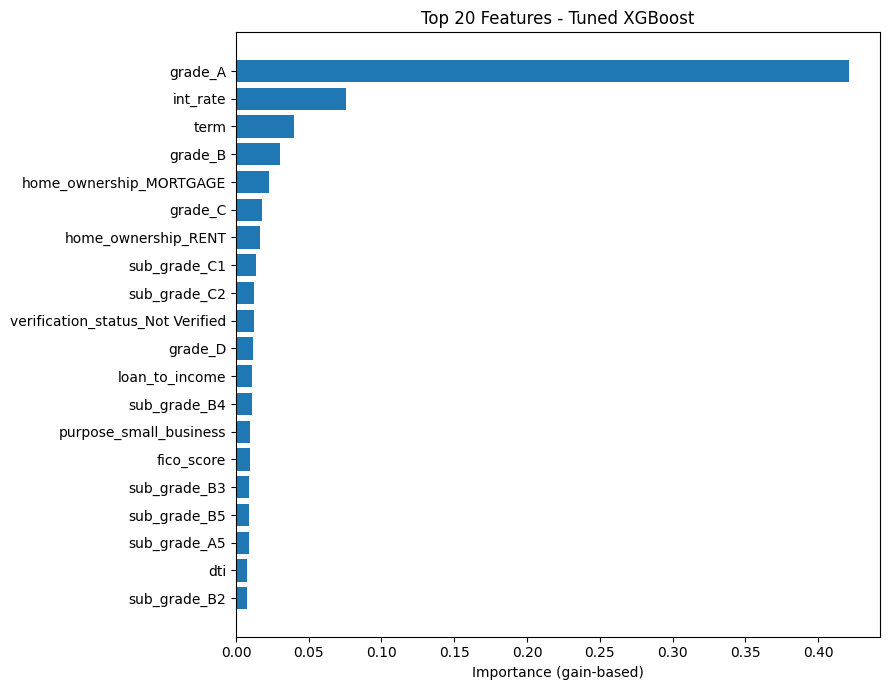

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Tuned XGBoost pipeline (already fitted)
best_xgb = best_estimators["xgboost"]

# Pull the fitted steps out of the pipeline
preprocessor_fitted = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["XGB"]

# Feature names after scaling + one-hot encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Clean the prefixes (num__, cat__) so the plot is readable
feature_names = [name.split("__", 1)[-1] for name in feature_names]

# Build importance table
importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(importance_df.head(20))

# Plot top 20
top_n = 20
plt.figure(figsize=(9, 7))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.xlabel("Importance (gain-based)")
plt.title(f"Top {top_n} Features - Tuned XGBoost")
plt.tight_layout()
plt.show()

In [57]:
# Group one-hot columns back to their original feature
def base_name(col):
    for cat in categorical_features:
        if col.startswith(cat + "_"):
            return cat
    return col

grouped = (
    importance_df.assign(base=importance_df["feature"].map(base_name))
    .groupby("base")["importance"].sum()
    .sort_values(ascending=False)
)
print(grouped.head(15))

base
grade                  0.492403
sub_grade              0.171519
int_rate               0.075289
purpose                0.061333
home_ownership         0.048134
term                   0.039877
verification_status    0.022049
loan_to_income         0.011169
fico_score             0.009756
dti                    0.007703
emp_length             0.005595
open_acc               0.005340
application_type       0.005135
pub_rec                0.005099
revol_bal              0.004899
Name: importance, dtype: float32


In [42]:
!pip install shap

You should consider upgrading via the 'C:\Data Science\DataScience_Projects\lending_club_default_risk_project\myenv\Scripts\python.exe -m pip install --upgrade pip' command.


c:\Data Science\DataScience_Projects\lending_club_default_risk_project\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


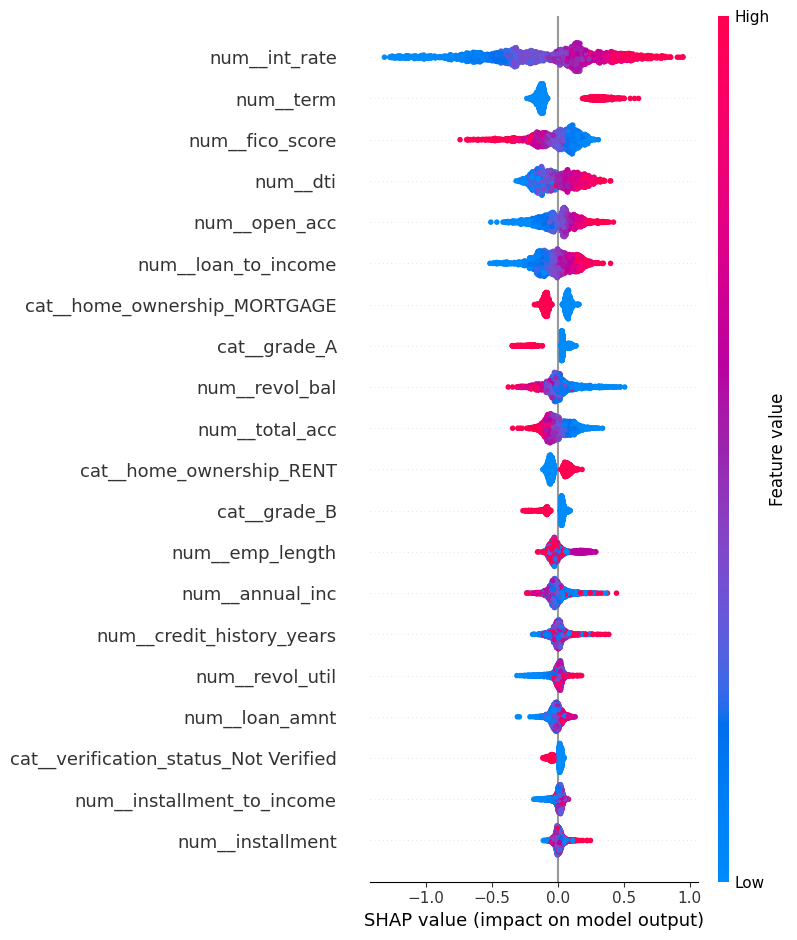

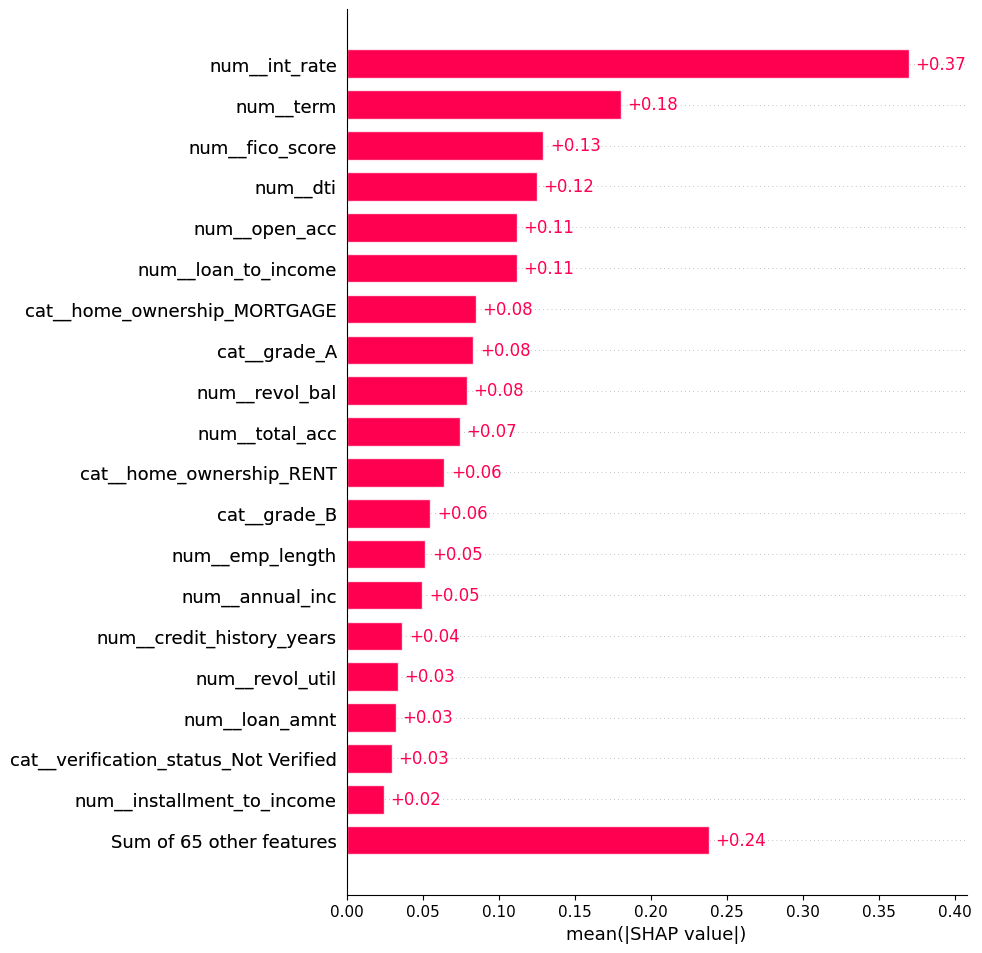

In [43]:
import shap
import pandas as pd

# Transform data through preprocessing steps only (not the model step) -
# SHAP needs the data in the same form the model actually sees it.
X_test_capped = best_xgb.named_steps["outlier_capper"].transform(X_test)
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test_capped)
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# SHAP on the full test set can be slow - sample for a stable, fast global view
sample_df = X_test_shap.sample(n=min(2000, len(X_test_shap)), random_state=RANDOM_STATE)

# Extract the actual XGBoost model from the pipeline
xgb_model = best_xgb.named_steps["XGB"]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(sample_df)

# =========================
# GLOBAL SUMMARY PLOT
# =========================
# One dot per (row, feature). Position = impact on prediction (toward
# default vs no-default). Color = the feature's actual value (high/low).
shap.summary_plot(shap_values, sample_df, max_display=20)

# =========================
# GLOBAL FEATURE IMPORTANCE (mean |SHAP value|)
# =========================
# Simpler ranked view - which features matter most overall, regardless
# of direction.
shap.plots.bar(shap_values, max_display=20)

Row index in X_test: 89444
Predicted default probability: 0.163
Actual label: 0


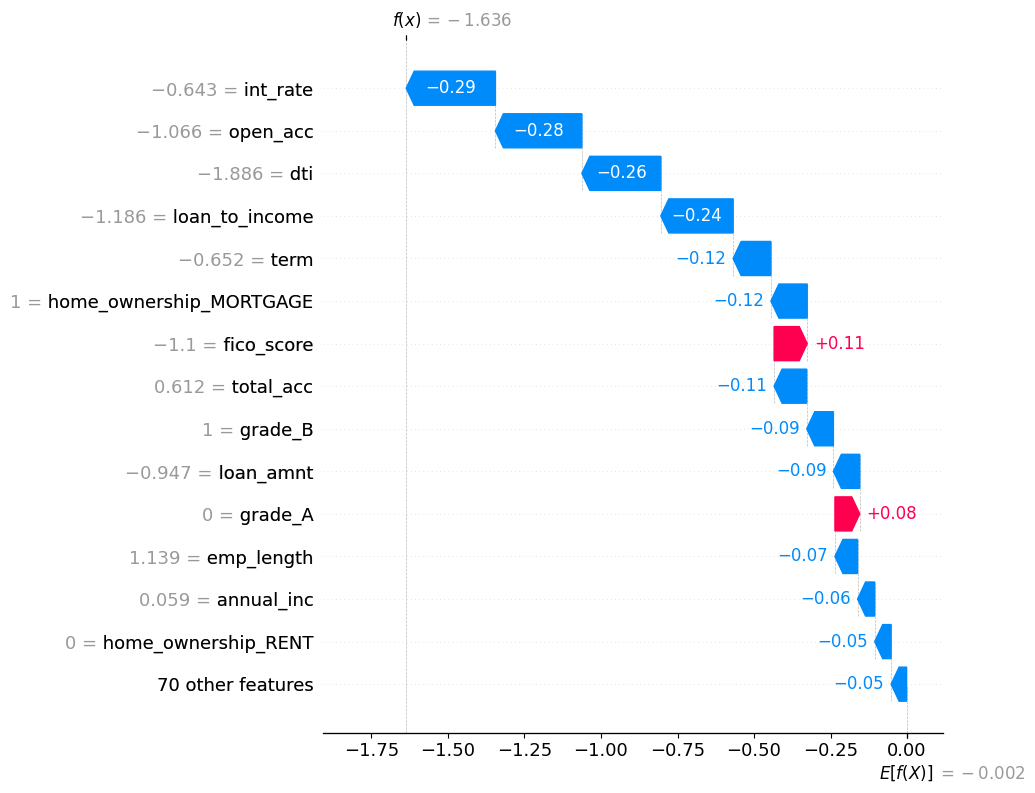

In [58]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

best_xgb = best_estimators["xgboost"]

# Pull out the fitted pipeline steps
outlier_capper = best_xgb.named_steps["outlier_capper"]
preprocessor_fitted = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["XGB"]

# Clean feature names (removes num__ / cat__ prefixes)
feature_names = [n.split("__", 1)[-1] for n in preprocessor_fitted.get_feature_names_out()]

# Transform a sample of test data the same way the pipeline does
X_test_sample = X_test.sample(2000, random_state=RANDOM_STATE)
X_capped = outlier_capper.transform(X_test_sample)
X_trans = preprocessor_fitted.transform(X_capped)
X_trans = pd.DataFrame(X_trans, columns=feature_names, index=X_test_sample.index)

# Build the explainer on the XGB model only
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_trans)   # Explanation object

# Pick ONE data point (change this position to explain any row)
i = 0
row_label = X_trans.index[i]
prob = xgb_model.predict_proba(X_trans.iloc[[i]])[0, 1]

print(f"Row index in X_test: {row_label}")
print(f"Predicted default probability: {prob:.3f}")
print(f"Actual label: {y_test.loc[row_label]}")

# Waterfall plot: how each feature pushes this loan toward default or not
shap.plots.waterfall(shap_values[i], max_display=15)

In [59]:
print(X_test_sample.iloc[i])   # original, human-readable values

loan_amnt                     6600.0
term                              36
int_rate                       10.99
installment                   216.05
grade                              B
sub_grade                         B4
emp_length                      10.0
home_ownership              MORTGAGE
annual_inc                   75000.0
verification_status         Verified
purpose                  credit_card
dti                             2.69
delinq_2yrs                      0.0
open_acc                         6.0
pub_rec                          1.0
revol_bal                     5726.0
revol_util                      70.7
total_acc                       32.0
application_type          Individual
fico_score                     662.0
loan_to_income                 0.088
installment_to_income       0.002881
credit_history_years       17.661875
Name: 89444, dtype: object


Predicted default probability: 0.163
Actual label: 0


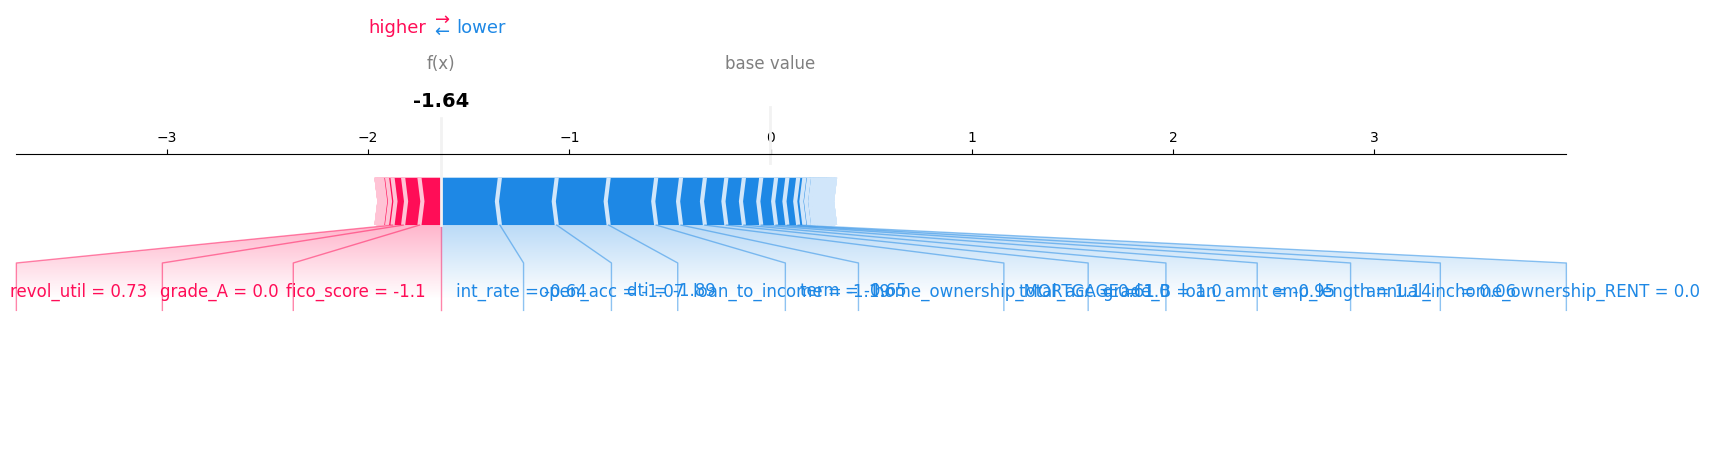

In [64]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

best_xgb = best_estimators["xgboost"]

outlier_capper = best_xgb.named_steps["outlier_capper"]
preprocessor_fitted = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["XGB"]

feature_names = [n.split("__", 1)[-1] for n in preprocessor_fitted.get_feature_names_out()]

# Transform a sample of test data the same way the pipeline does
X_test_sample = X_test.sample(2000, random_state=RANDOM_STATE)
X_capped = outlier_capper.transform(X_test_sample)
X_trans = preprocessor_fitted.transform(X_capped)
X_trans = pd.DataFrame(X_trans, columns=feature_names, index=X_test_sample.index)

# Explainer on the XGB model only
explainer_shap = shap.TreeExplainer(xgb_model)
shap_values_all = explainer_shap.shap_values(X_trans)

# Pick ONE loan (change i to explain another)
i = 0
instance = X_trans.iloc[i]
shap_values_instance = shap_values_all[i]

print(f"Predicted default probability: {xgb_model.predict_proba(X_trans.iloc[[i]])[0, 1]:.3f}")
print(f"Actual label: {y_test.loc[X_trans.index[i]]}")

# Force plot (single row style, like your image)
instance_rounded = instance.round(2)

shap.force_plot(
    explainer_shap.expected_value,
    shap_values_instance,
    instance_rounded,
    matplotlib=True,
    contribution_threshold=0.02,   # hides tiny features, tune between 0.05 and 0.15
    figsize=(20, 4)
)
plt.show()